# ENSO and Cattle Slaughter Analysis

Analyzes the relationship between ENSO (El Niño-Southern Oscillation) phases and cattle slaughter (raw and normalized) in USDA Regions 4 & 6.

**Primary Index: RONI (Relative Oceanic Niño Index)** — NOAA's new standard (adopted 2026), which subtracts the tropical mean SST warming trend from Niño 3.4, better reflecting ocean-atmosphere coupling under climate change.

**Data Sources:**
- RONI (Relative Oceanic Niño Index) from NOAA CPC — primary
- ONI (Oceanic Niño Index) from NOAA CPC — secondary/comparison
- USDA cattle slaughter data (weekly)
- NASS cattle inventory (annual, for normalization)

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from io import StringIO
import requests

import config

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## 1. Download ENSO Data from NOAA

The **RONI** (Relative Oceanic Niño Index) is computed as the 3-month running mean of ERSSTv5 SST anomalies in the Niño 3.4 region (5°N–5°S, 120°–170°W) with the average tropical mean (20°N–20°S) SST anomalies subtracted, then variance-adjusted to match the original Niño 3.4 index. Thresholds: El Niño > +0.5°C, La Niña < -0.5°C.

In [2]:
# Download RONI from NOAA CPC
# The RONI page provides a table; we scrape it or use the known URL pattern
# RONI data is in the same format as ONI (SEAS YR TOTAL ANOM)
roni_url = 'https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/roni.ascii.txt'

try:
    response = requests.get(roni_url)
    response.raise_for_status()
    roni_df = pd.read_csv(StringIO(response.text), delim_whitespace=True)
    print(f"RONI downloaded directly: {roni_df.shape[0]} records")
except Exception:
    # If direct URL fails, parse from the known table data
    # RONI is published as a wide table (Year × 12 seasons)
    # We'll construct it from the scraped data
    print("Direct RONI file not available, constructing from published table...")
    
    # RONI data from NOAA CPC (scraped 2026-05-09)
    roni_wide_text = """Year DJF JFM FMA MAM AMJ MJJ JJA JAS ASO SON OND NDJ
1950 -1.5 -1.3 -1.1 -1.1 -1.0 -0.7 -0.4 -0.2 -0.2 -0.3 -0.4 -0.6
1951 -0.5 -0.2 0.3 0.6 0.6 0.7 0.7 0.8 0.9 1.0 0.9 0.8
1952 0.6 0.4 0.4 0.4 0.3 0.1 0.0 0.0 0.1 0.0 0.0 0.2
1953 0.5 0.8 0.8 0.8 0.8 0.8 0.7 0.7 0.7 0.8 0.8 0.9
1954 1.0 0.7 0.1 -0.2 -0.3 -0.3 -0.5 -0.7 -0.8 -0.7 -0.6 -0.4
1955 -0.4 -0.3 -0.3 -0.4 -0.4 -0.4 -0.4 -0.6 -1.0 -1.4 -1.6 -1.3
1956 -0.7 -0.3 -0.2 -0.1 0.0 -0.1 -0.3 -0.3 -0.3 -0.3 -0.4 -0.2
1957 0.0 0.4 0.7 1.0 1.1 1.2 1.2 1.3 1.2 1.3 1.5 1.9
1958 2.0 1.9 1.4 1.1 0.8 0.7 0.5 0.3 0.2 0.3 0.4 0.7
1959 0.8 0.8 0.7 0.4 0.3 -0.1 -0.2 -0.4 -0.3 -0.3 -0.1 0.0
1960 0.0 0.0 0.0 0.1 0.1 0.0 0.1 0.2 0.2 0.1 0.0 0.0
1961 0.1 0.1 0.0 0.1 0.3 0.3 0.2 -0.1 -0.3 -0.3 -0.2 -0.1
1962 -0.1 -0.1 -0.1 -0.2 -0.3 -0.2 -0.1 -0.2 -0.2 -0.4 -0.5 -0.5
1963 -0.4 -0.1 0.2 0.2 0.2 0.4 0.7 1.0 1.0 1.1 1.2 1.3
1964 1.1 0.7 0.1 -0.4 -0.6 -0.6 -0.6 -0.6 -0.7 -0.8 -0.7 -0.5
1965 -0.2 0.1 0.2 0.4 0.6 1.0 1.4 1.7 1.9 2.0 2.0 1.9
1966 1.7 1.5 1.3 0.9 0.5 0.3 0.3 0.1 0.0 -0.1 -0.1 -0.2
1967 -0.2 -0.2 -0.4 -0.4 -0.2 0.2 0.3 0.1 0.0 -0.1 0.0 0.0
1968 -0.2 -0.3 -0.3 -0.2 0.2 0.5 0.7 0.6 0.5 0.6 0.8 1.1
1969 1.2 1.1 0.9 0.5 0.4 0.2 0.2 0.4 0.7 0.8 0.7 0.6
1970 0.5 0.3 0.3 0.1 0.0 -0.3 -0.6 -0.7 -0.7 -0.6 -0.7 -0.9
1971 -1.0 -1.0 -0.8 -0.6 -0.5 -0.4 -0.4 -0.4 -0.5 -0.5 -0.5 -0.5
1972 -0.3 0.0 0.4 0.8 0.9 1.1 1.3 1.5 1.7 2.0 2.2 2.3
1973 2.0 1.4 0.6 -0.2 -0.8 -1.1 -1.2 -1.4 -1.5 -1.8 -1.9 -1.9
1974 -1.5 -1.2 -0.9 -0.9 -0.8 -0.6 -0.4 -0.2 -0.2 -0.4 -0.4 -0.2
1975 -0.1 -0.1 -0.3 -0.5 -0.6 -0.8 -0.9 -0.9 -1.0 -1.0 -1.1 -1.1
1976 -1.0 -0.6 -0.3 -0.1 0.0 0.2 0.5 0.7 0.9 1.1 1.1 1.1
1977 1.0 0.9 0.5 0.3 0.2 0.4 0.4 0.6 0.8 1.0 1.1 1.1
1978 0.9 0.6 0.1 -0.2 -0.4 -0.3 -0.3 -0.3 -0.2 0.0 0.2 0.2
1979 0.2 0.2 0.2 0.2 0.1 -0.1 0.0 0.2 0.4 0.5 0.5 0.7
1980 0.6 0.5 0.3 0.2 0.3 0.3 0.2 0.0 0.0 0.1 0.2 0.2
1981 0.0 -0.3 -0.3 -0.3 -0.3 -0.3 -0.3 -0.2 -0.1 -0.2 -0.2 0.0
1982 0.1 0.3 0.4 0.6 0.8 0.8 0.9 1.3 1.8 2.2 2.4 2.5
1983 2.5 2.2 1.7 1.4 1.0 0.6 0.1 -0.2 -0.6 -0.9 -1.1 -1.0
1984 -0.5 -0.3 -0.3 -0.5 -0.6 -0.4 -0.2 -0.1 -0.1 -0.5 -0.8 -1.0
1985 -0.8 -0.6 -0.6 -0.7 -0.7 -0.5 -0.4 -0.3 -0.2 -0.2 -0.1 -0.2
1986 -0.3 -0.3 -0.2 -0.1 -0.1 -0.1 0.3 0.6 0.9 1.2 1.4 1.5
1987 1.6 1.5 1.3 1.0 0.9 1.1 1.3 1.6 1.5 1.3 1.0 0.9
1988 0.7 0.3 -0.2 -0.7 -1.4 -1.7 -1.6 -1.3 -1.4 -1.6 -1.9 -1.9
1989 -1.7 -1.4 -1.1 -0.8 -0.6 -0.4 -0.3 -0.3 -0.2 -0.2 -0.1 0.0
1990 0.2 0.3 0.3 0.3 0.2 0.2 0.3 0.4 0.4 0.4 0.4 0.5
1991 0.6 0.5 0.4 0.4 0.5 0.7 0.8 0.8 0.9 1.2 1.7 2.1
1992 2.3 2.2 2.0 1.7 1.4 0.9 0.5 0.3 0.2 0.1 0.1 0.3
1993 0.5 0.7 0.9 1.0 0.9 0.7 0.5 0.5 0.5 0.4 0.3 0.3
1994 0.3 0.3 0.4 0.5 0.6 0.6 0.7 0.8 1.0 1.1 1.3 1.4
1995 1.3 1.0 0.7 0.4 0.1 -0.1 -0.3 -0.5 -0.7 -0.9 -0.9 -0.9
1996 -0.9 -0.8 -0.6 -0.4 -0.3 -0.3 -0.2 -0.2 -0.2 -0.3 -0.3 -0.3
1997 -0.2 -0.1 0.2 0.5 1.0 1.3 1.7 2.0 2.3 2.4 2.4 2.3
1998 2.2 1.8 1.3 0.8 0.1 -0.5 -1.2 -1.4 -1.5 -1.5 -1.6 -1.6
1999 -1.5 -1.3 -1.1 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.1 -1.4 -1.6
2000 -1.7 -1.4 -1.1 -0.8 -0.6 -0.5 -0.4 -0.4 -0.4 -0.6 -0.7 -0.7
2001 -0.6 -0.5 -0.5 -0.5 -0.3 -0.1 0.0 0.0 0.0 -0.2 -0.2 -0.3
2002 -0.1 0.0 0.0 0.1 0.4 0.7 0.9 1.1 1.3 1.4 1.5 1.2
2003 0.9 0.5 0.2 -0.2 -0.4 -0.3 0.0 0.2 0.2 0.2 0.3 0.3
2004 0.3 0.1 0.1 0.2 0.3 0.5 0.7 0.8 0.9 0.8 0.7 0.7
2005 0.6 0.4 0.3 0.3 0.2 0.0 -0.1 -0.1 0.0 -0.2 -0.5 -0.8
2006 -0.9 -0.9 -0.6 -0.4 -0.1 0.0 0.1 0.3 0.5 0.8 0.9 0.9
2007 0.6 0.2 -0.2 -0.4 -0.4 -0.5 -0.6 -0.8 -1.0 -1.3 -1.4 -1.5
2008 -1.6 -1.5 -1.3 -0.9 -0.8 -0.5 -0.3 -0.2 -0.3 -0.4 -0.6 -0.8
2009 -0.9 -0.8 -0.7 -0.4 -0.1 0.1 0.3 0.4 0.6 0.9 1.3 1.6
2010 1.5 1.1 0.6 0.1 -0.5 -1.0 -1.3 -1.5 -1.7 -1.7 -1.7 -1.6
2011 -1.4 -1.2 -0.9 -0.7 -0.5 -0.3 -0.4 -0.5 -0.7 -0.9 -1.0 -1.0
2012 -0.8 -0.6 -0.6 -0.5 -0.3 0.0 0.3 0.4 0.4 0.2 -0.1 -0.4
2013 -0.6 -0.6 -0.5 -0.4 -0.4 -0.4 -0.4 -0.3 -0.3 -0.2 -0.2 -0.3
2014 -0.5 -0.5 -0.3 0.0 0.1 0.0 -0.1 -0.1 0.1 0.4 0.5 0.6
2015 0.5 0.4 0.5 0.6 0.8 1.0 1.3 1.6 1.9 2.2 2.3 2.4
2016 2.2 1.8 1.3 0.5 -0.1 -0.6 -0.9 -1.0 -1.1 -1.1 -1.1 -1.0
2017 -0.7 -0.5 -0.3 -0.1 0.1 0.1 -0.2 -0.5 -0.7 -1.0 -1.1 -1.3
2018 -1.1 -1.0 -0.9 -0.7 -0.3 0.0 0.1 0.2 0.4 0.7 0.8 0.7
2019 0.6 0.6 0.6 0.5 0.3 0.2 0.0 -0.1 0.0 0.1 0.2 0.2
2020 0.1 0.1 0.0 -0.3 -0.6 -0.8 -0.8 -0.9 -1.2 -1.5 -1.5 -1.4
2021 -1.2 -1.0 -1.0 -0.8 -0.6 -0.5 -0.6 -0.7 -0.9 -1.1 -1.2 -1.2
2022 -1.2 -1.2 -1.3 -1.3 -1.2 -1.0 -0.9 -1.0 -1.1 -1.1 -1.0 -1.0
2023 -0.8 -0.6 -0.4 -0.2 0.1 0.4 0.6 0.9 1.1 1.4 1.5 1.5
2024 1.2 0.9 0.5 0.1 -0.3 -0.5 -0.5 -0.6 -0.8 -0.8 -0.9 -1.1
2025 -1.1 -0.9 -0.7 -0.5 -0.5 -0.4 -0.5 -0.6 -0.8 -0.9 -0.9 -1.0
2026 -0.9 -0.7 -0.5"""
    
    roni_wide = pd.read_csv(StringIO(roni_wide_text), delim_whitespace=True)
    
    # Melt wide to long format
    season_cols = ['DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO', 'SON', 'OND', 'NDJ']
    roni_df = roni_wide.melt(id_vars='Year', value_vars=season_cols, var_name='SEAS', value_name='roni')
    roni_df = roni_df.rename(columns={'Year': 'YR'})
    roni_df = roni_df.dropna(subset=['roni'])
    print(f"RONI constructed: {roni_df.shape[0]} records, {roni_df['YR'].min()}-{roni_df['YR'].max()}")

print(f"\nRONI range: {roni_df['roni'].min():.2f} to {roni_df['roni'].max():.2f}")
roni_df.head()

Direct RONI file not available, constructing from published table...
RONI constructed: 915 records, 1950-2026

RONI range: -1.90 to 2.50


/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/4193472264.py:97: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  roni_wide = pd.read_csv(StringIO(roni_wide_text), delim_whitespace=True)


,YR,SEAS,roni
0,1950,DJF,-1.5
1,1951,DJF,-0.5
2,1952,DJF,0.6
3,1953,DJF,0.5
4,1954,DJF,1.0


In [3]:
# Also download traditional ONI for comparison
oni_url = 'https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt'
response = requests.get(oni_url)
response.raise_for_status()
oni_df = pd.read_csv(StringIO(response.text), delim_whitespace=True)
print(f"ONI data (for comparison): {oni_df.shape[0]} records, {oni_df['YR'].min()}-{oni_df['YR'].max()}")

ONI data (for comparison): 915 records, 1950-2026


/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/482404758.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  oni_df = pd.read_csv(StringIO(response.text), delim_whitespace=True)


In [4]:
# Process RONI into monthly time series
season_to_month = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4, 'AMJ': 5, 'MJJ': 6,
    'JJA': 7, 'JAS': 8, 'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}

roni_df['month'] = roni_df['SEAS'].map(season_to_month)
roni_df['date'] = pd.to_datetime(roni_df[['YR', 'month']].rename(columns={'YR': 'year'}).assign(day=1))

# Classify ENSO phase using RONI (same thresholds: ±0.5°C)
roni_df['enso_phase'] = pd.cut(
    roni_df['roni'],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=['La Niña', 'Neutral', 'El Niño']
)

# Process ONI similarly
oni_df['month'] = oni_df['SEAS'].map(season_to_month)
oni_df['date'] = pd.to_datetime(oni_df[['YR', 'month']].rename(columns={'YR': 'year'}).assign(day=1))
oni_df = oni_df.rename(columns={'ANOM': 'oni'})

print(f"RONI range: {roni_df['roni'].min():.2f} to {roni_df['roni'].max():.2f}")
print(f"\nENSO phase distribution (RONI-based):")
print(roni_df['enso_phase'].value_counts())
print(f"\nKey difference from ONI: RONI removes tropical mean warming trend,")
print(f"so recent La Niña events appear stronger and El Niño events slightly weaker.")

RONI range: -1.90 to 2.50

ENSO phase distribution (RONI-based):
enso_phase
Neutral    422
La Niña    262
El Niño    231
Name: count, dtype: int64

Key difference from ONI: RONI removes tropical mean warming trend,
so recent La Niña events appear stronger and El Niño events slightly weaker.


In [5]:
# Save ENSO data locally for reproducibility
enso_dir = config.CATTLE_DATA_DIR
roni_df[['date', 'roni', 'enso_phase']].to_csv(enso_dir / 'noaa_roni.csv', index=False)
oni_df[['date', 'oni']].to_csv(enso_dir / 'noaa_oni.csv', index=False)
print(f"Saved RONI and ONI data to {enso_dir}")

Saved RONI and ONI data to /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/notebooks/03_analysis/../../data/cattle_data


## 2. Load and Prepare Cattle Data

In [6]:
# Load cattle slaughter data
cattle_df = pd.read_csv(config.CATTLE_DATA_FILE, parse_dates=['date'])
print(f"Cattle data: {cattle_df.shape[0]} weeks, {cattle_df['date'].min().date()} to {cattle_df['date'].max().date()}")

# Focus on regions 4 and 6 (beef-dairy slaughter)
cattle_weekly = cattle_df[['date', 'region_4_beef_dairy', 'region_6_beef_dairy']].copy()
cattle_weekly = cattle_weekly.rename(columns={
    'region_4_beef_dairy': 'slaughter_r4',
    'region_6_beef_dairy': 'slaughter_r6'
})
cattle_weekly['slaughter_total'] = cattle_weekly['slaughter_r4'] + cattle_weekly['slaughter_r6']
cattle_weekly['year'] = cattle_weekly['date'].dt.year
cattle_weekly['month'] = cattle_weekly['date'].dt.month

print(f"\nRegion 4 mean: {cattle_weekly['slaughter_r4'].mean():.1f} thousand head/week")
print(f"Region 6 mean: {cattle_weekly['slaughter_r6'].mean():.1f} thousand head/week")
cattle_weekly.head()

Cattle data: 2254 weeks, 1984-01-07 to 2027-03-13

Region 4 mean: 13.3 thousand head/week
Region 6 mean: 19.1 thousand head/week


,date,slaughter_r4,slaughter_r6,slaughter_total,year,month
0,1984-01-07,21.3,29.9,51.2,1984,1
1,1984-01-14,19.1,20.9,40.0,1984,1
2,1984-01-21,17.9,22.0,39.9,1984,1
3,1984-01-28,18.2,24.8,43.0,1984,1
4,1984-02-04,17.2,20.8,38.0,1984,2


In [7]:
# Load inventory data for normalization
inventory_df = pd.read_csv(config.CATTLE_DATA_DIR / 'nass_cattle_inventory.csv')
print(f"Inventory data: {inventory_df.shape[0]} records")
print(inventory_df.head())

# Pivot to get region columns
inv_pivot = inventory_df.pivot(index='year', columns='region', values='regional_inventory_head')
inv_pivot.columns = [f'inventory_{col}' for col in inv_pivot.columns]

# Merge inventory with cattle weekly data
cattle_weekly = cattle_weekly.merge(inv_pivot, left_on='year', right_index=True, how='left')

# Calculate normalized slaughter rate (per 1000 head of inventory, annualized)
cattle_weekly['norm_slaughter_r4'] = (
    cattle_weekly['slaughter_r4'] * 1000 / cattle_weekly['inventory_region_4'] * 1e3
)
cattle_weekly['norm_slaughter_r6'] = (
    cattle_weekly['slaughter_r6'] * 1000 / cattle_weekly['inventory_region_6'] * 1e3
)
cattle_weekly['norm_slaughter_total'] = (
    cattle_weekly['slaughter_total'] * 1000 / 
    (cattle_weekly['inventory_region_4'] + cattle_weekly['inventory_region_6']) * 1e3
)

print(f"\nNormalized slaughter rate (per 1000 head):")
print(f"  Region 4: {cattle_weekly['norm_slaughter_r4'].mean():.3f}")
print(f"  Region 6: {cattle_weekly['norm_slaughter_r6'].mean():.3f}")

Inventory data: 86 records
   year    region  regional_inventory_head
0  1984  region_4                 14779000
1  1984  region_6                 24540000
2  1985  region_4                 14268000
3  1985  region_6                 23980000
4  1986  region_4                 13745000

Normalized slaughter rate (per 1000 head):
  Region 4: 1.174
  Region 6: 0.852


## 3. Merge ENSO with Cattle Data

In [8]:
# Assign monthly RONI to each week based on the month the week falls in
roni_monthly = roni_df[['date', 'roni', 'enso_phase']].copy()
roni_monthly['year'] = roni_monthly['date'].dt.year
roni_monthly['month'] = roni_monthly['date'].dt.month

# Merge on year-month
merged = cattle_weekly.merge(
    roni_monthly[['year', 'month', 'roni', 'enso_phase']],
    on=['year', 'month'],
    how='left'
)

# Also add ONI for comparison
oni_monthly = oni_df[['date', 'oni']].copy()
oni_monthly['year'] = oni_monthly['date'].dt.year
oni_monthly['month'] = oni_monthly['date'].dt.month

merged = merged.merge(
    oni_monthly[['year', 'month', 'oni']],
    on=['year', 'month'],
    how='left'
)

# Drop rows without ENSO data
merged = merged.dropna(subset=['roni'])
print(f"Merged dataset: {merged.shape[0]} weeks with ENSO + cattle data")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"\nENSO phase counts (RONI-based):")
print(merged['enso_phase'].value_counts())

Merged dataset: 2204 weeks with ENSO + cattle data
Date range: 1984-01-07 to 2026-03-28

ENSO phase counts (RONI-based):
enso_phase
Neutral    894
La Niña    820
El Niño    490
Name: count, dtype: int64


## 4. ENSO Phase vs. Cattle Slaughter

In [9]:
# Summary statistics by ENSO phase
phase_stats = merged.groupby('enso_phase').agg({
    'slaughter_r4': ['mean', 'std', 'count'],
    'slaughter_r6': ['mean', 'std', 'count'],
    'norm_slaughter_r4': ['mean', 'std'],
    'norm_slaughter_r6': ['mean', 'std'],
}).round(3)

print("Slaughter statistics by ENSO phase:")
print("=" * 70)
phase_stats

Slaughter statistics by ENSO phase:


/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/3169438900.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_stats = merged.groupby('enso_phase').agg({


slaughter_r4              slaughter_r6               \
                   mean    std count         mean    std count   
enso_phase                                                       
La Niña          13.150  2.763   809       20.373  4.825   809   
Neutral          13.081  3.065   894       18.735  4.750   894   
El Niño          14.136  4.546   490       17.567  4.353   490   

           norm_slaughter_r4        norm_slaughter_r6         
                        mean    std              mean    std  
enso_phase                                                    
La Niña                1.201  0.200             0.914  0.231  
Neutral                1.133  0.196             0.837  0.221  
El Niño                1.203  0.325             0.779  0.208

/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/1996622985.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='enso_phase', y=col, order=order, palette=colors, ax=ax)
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/1996622985.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='enso_phase', y=col, order=order, palette=colors, ax=ax)
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/1996622985.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='

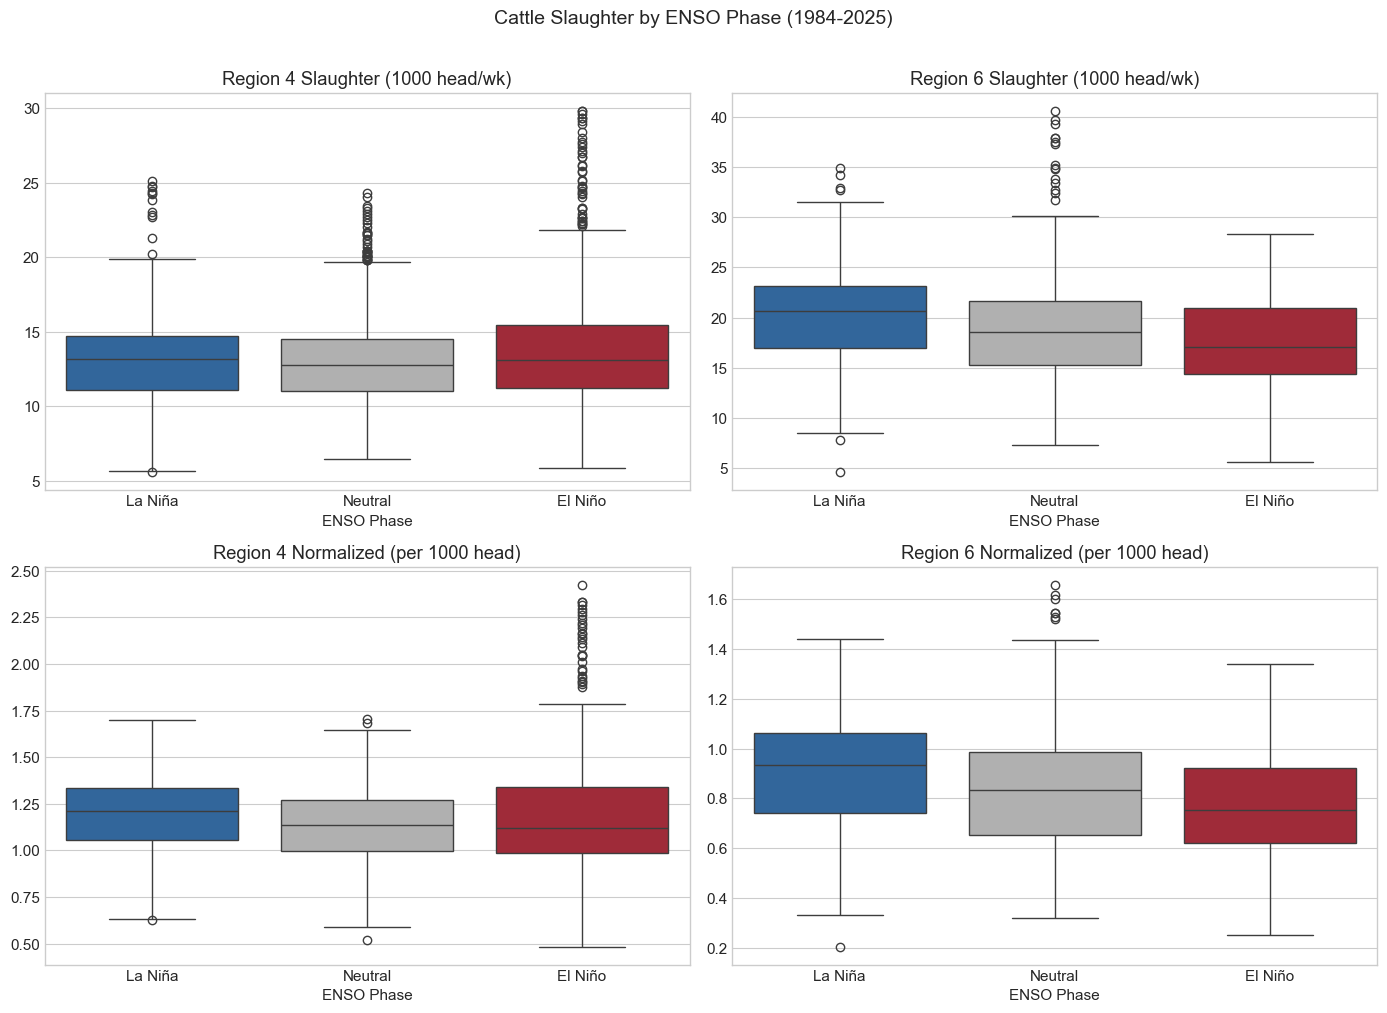

In [10]:
# Box plots: slaughter by ENSO phase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title in zip(
    axes.flat,
    ['slaughter_r4', 'slaughter_r6', 'norm_slaughter_r4', 'norm_slaughter_r6'],
    ['Region 4 Slaughter (1000 head/wk)', 'Region 6 Slaughter (1000 head/wk)',
     'Region 4 Normalized (per 1000 head)', 'Region 6 Normalized (per 1000 head)']
):
    order = ['La Niña', 'Neutral', 'El Niño']
    colors = ['#2166AC', '#B0B0B0', '#B2182B']
    sns.boxplot(data=merged, x='enso_phase', y=col, order=order, palette=colors, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('ENSO Phase')
    ax.set_ylabel('')

plt.suptitle('Cattle Slaughter by ENSO Phase (1984-2025)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'enso_slaughter_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Kruskal-Wallis test (non-parametric ANOVA) for differences between ENSO phases
print("Kruskal-Wallis test: Slaughter differs by ENSO phase?")
print("=" * 60)

for col, label in [
    ('slaughter_r4', 'Region 4 (raw)'),
    ('slaughter_r6', 'Region 6 (raw)'),
    ('norm_slaughter_r4', 'Region 4 (normalized)'),
    ('norm_slaughter_r6', 'Region 6 (normalized)'),
]:
    groups = [g[col].dropna().values for _, g in merged.groupby('enso_phase')]
    stat, pval = stats.kruskal(*groups)
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {label:30s} H={stat:8.2f}  p={pval:.4e}  {sig}")

Kruskal-Wallis test: Slaughter differs by ENSO phase?
  Region 4 (raw)                 H=    9.00  p=1.1130e-02  *
  Region 6 (raw)                 H=  114.78  p=1.1913e-25  ***
  Region 4 (normalized)          H=   45.11  p=1.5991e-10  ***
  Region 6 (normalized)          H=  116.68  p=4.5987e-26  ***


/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/922663752.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[col].dropna().values for _, g in merged.groupby('enso_phase')]


## 5. Seasonal ENSO Effects

/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/2568645157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='enso_phase', y='norm_slaughter_total',
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/2568645157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='enso_phase', y='norm_slaughter_total',
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/2568645157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='enso_phase', y='norm_slaughter_tot

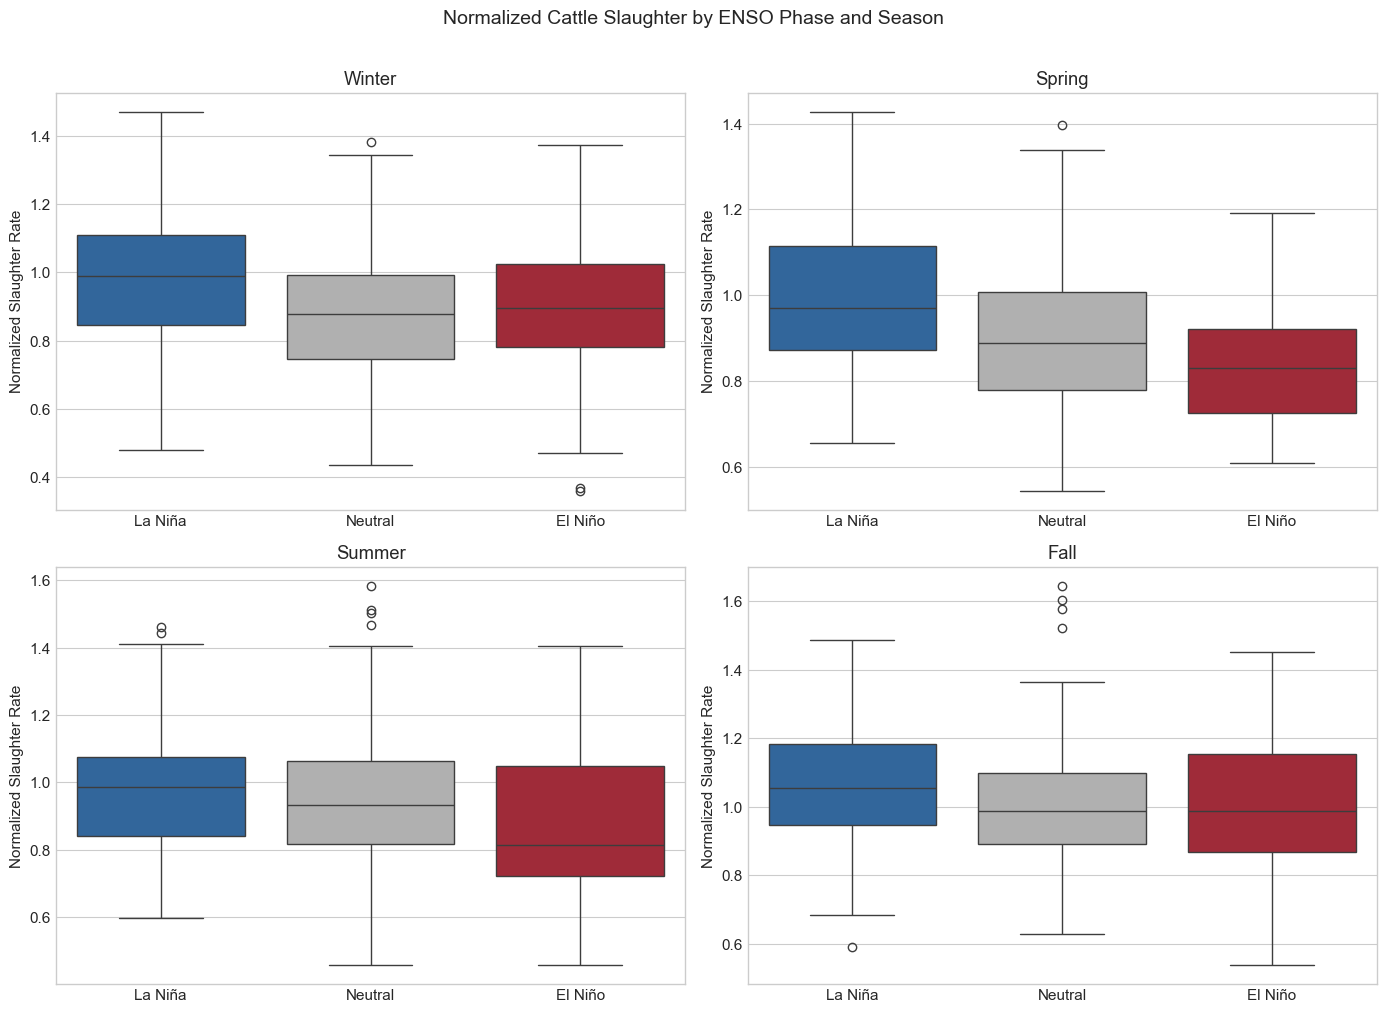

In [12]:
# ENSO effects may be strongest in certain seasons
merged['season'] = merged['month'].map(
    {12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Spring', 4: 'Spring', 5: 'Spring',
     6: 'Summer', 7: 'Summer', 8: 'Summer',
     9: 'Fall', 10: 'Fall', 11: 'Fall'}
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

for ax, season in zip(axes.flat, season_order):
    subset = merged[merged['season'] == season]
    order = ['La Niña', 'Neutral', 'El Niño']
    colors = ['#2166AC', '#B0B0B0', '#B2182B']
    sns.boxplot(data=subset, x='enso_phase', y='norm_slaughter_total',
                order=order, palette=colors, ax=ax)
    ax.set_title(f'{season}')
    ax.set_xlabel('')
    ax.set_ylabel('Normalized Slaughter Rate')

plt.suptitle('Normalized Cattle Slaughter by ENSO Phase and Season', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'enso_seasonal_slaughter.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Seasonal Kruskal-Wallis
print("Seasonal Kruskal-Wallis: Normalized slaughter differs by ENSO phase?")
print("=" * 60)

for season in season_order:
    subset = merged[merged['season'] == season]
    groups = [g['norm_slaughter_total'].dropna().values for _, g in subset.groupby('enso_phase')]
    if all(len(g) > 5 for g in groups):
        stat, pval = stats.kruskal(*groups)
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"  {season:10s} H={stat:8.2f}  p={pval:.4e}  {sig}")

Seasonal Kruskal-Wallis: Normalized slaughter differs by ENSO phase?
  Winter     H=   29.76  p=3.4480e-07  ***
  Spring     H=   51.42  p=6.8119e-12  ***
  Summer     H=   23.35  p=8.4844e-06  ***
  Fall       H=   12.61  p=1.8293e-03  **


/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/1668282128.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g['norm_slaughter_total'].dropna().values for _, g in subset.groupby('enso_phase')]


## 6. Correlation and Lag Analysis

In [14]:
# Cross-correlation between RONI and cattle slaughter at various lags
# ENSO teleconnections can take weeks/months to manifest in cattle stress

max_lag_weeks = 26  # up to 6 months
lag_range = range(0, max_lag_weeks + 1)

results = []
for lag in lag_range:
    for col, label in [
        ('norm_slaughter_r4', 'Region 4'),
        ('norm_slaughter_r6', 'Region 6'),
        ('norm_slaughter_total', 'Total'),
    ]:
        # Lag RONI relative to slaughter (positive lag = RONI leads)
        roni_lagged = merged['roni'].shift(lag)
        valid = merged[[col]].assign(roni_lag=roni_lagged).dropna()
        if len(valid) > 30:
            r, p = stats.pearsonr(valid['roni_lag'], valid[col])
            results.append({'lag_weeks': lag, 'region': label, 'r': r, 'p': p})

lag_df = pd.DataFrame(results)
print(f"Computed correlations for {len(lag_range)} lags × 3 regions")

Computed correlations for 27 lags × 3 regions


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r

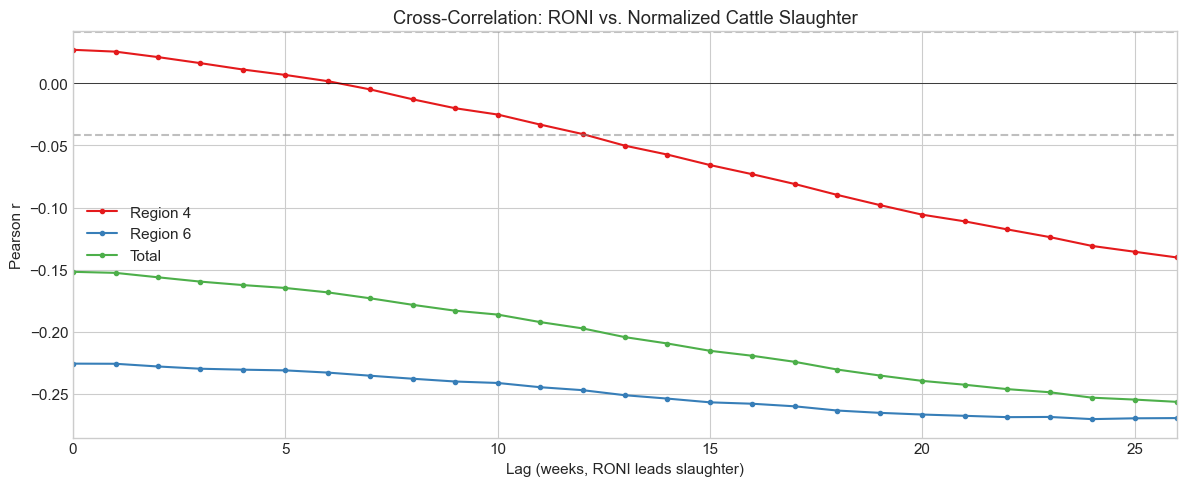


Peak correlations (by absolute value):
  Region 4: r=-0.1402 at lag=26 weeks (p=5.5259e-11)
  Region 6: r=-0.2705 at lag=24 weeks (p=1.1356e-37)
  Total: r=-0.2566 at lag=26 weeks (p=6.4989e-34)


In [15]:
# Plot cross-correlation
fig, ax = plt.subplots(figsize=(12, 5))

for region, color in [('Region 4', '#E41A1C'), ('Region 6', '#377EB8'), ('Total', '#4DAF4A')]:
    subset = lag_df[lag_df['region'] == region]
    ax.plot(subset['lag_weeks'], subset['r'], '-o', color=color, markersize=3, label=region)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lag (weeks, RONI leads slaughter)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-Correlation: RONI vs. Normalized Cattle Slaughter')
ax.legend()
ax.set_xlim(0, max_lag_weeks)

# Mark significance threshold (approximate for large N)
n = merged.shape[0]
sig_threshold = 1.96 / np.sqrt(n)
ax.axhline(sig_threshold, color='gray', linestyle='--', alpha=0.5, label=f'p=0.05 threshold')
ax.axhline(-sig_threshold, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roni_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print peak correlations
print("\nPeak correlations (by absolute value):")
for region in ['Region 4', 'Region 6', 'Total']:
    subset = lag_df[lag_df['region'] == region]
    peak_idx = subset['r'].abs().idxmax()
    peak = subset.loc[peak_idx]
    print(f"  {region}: r={peak['r']:.4f} at lag={peak['lag_weeks']:.0f} weeks (p={peak['p']:.4e})")

## 7. Time Series Comparison

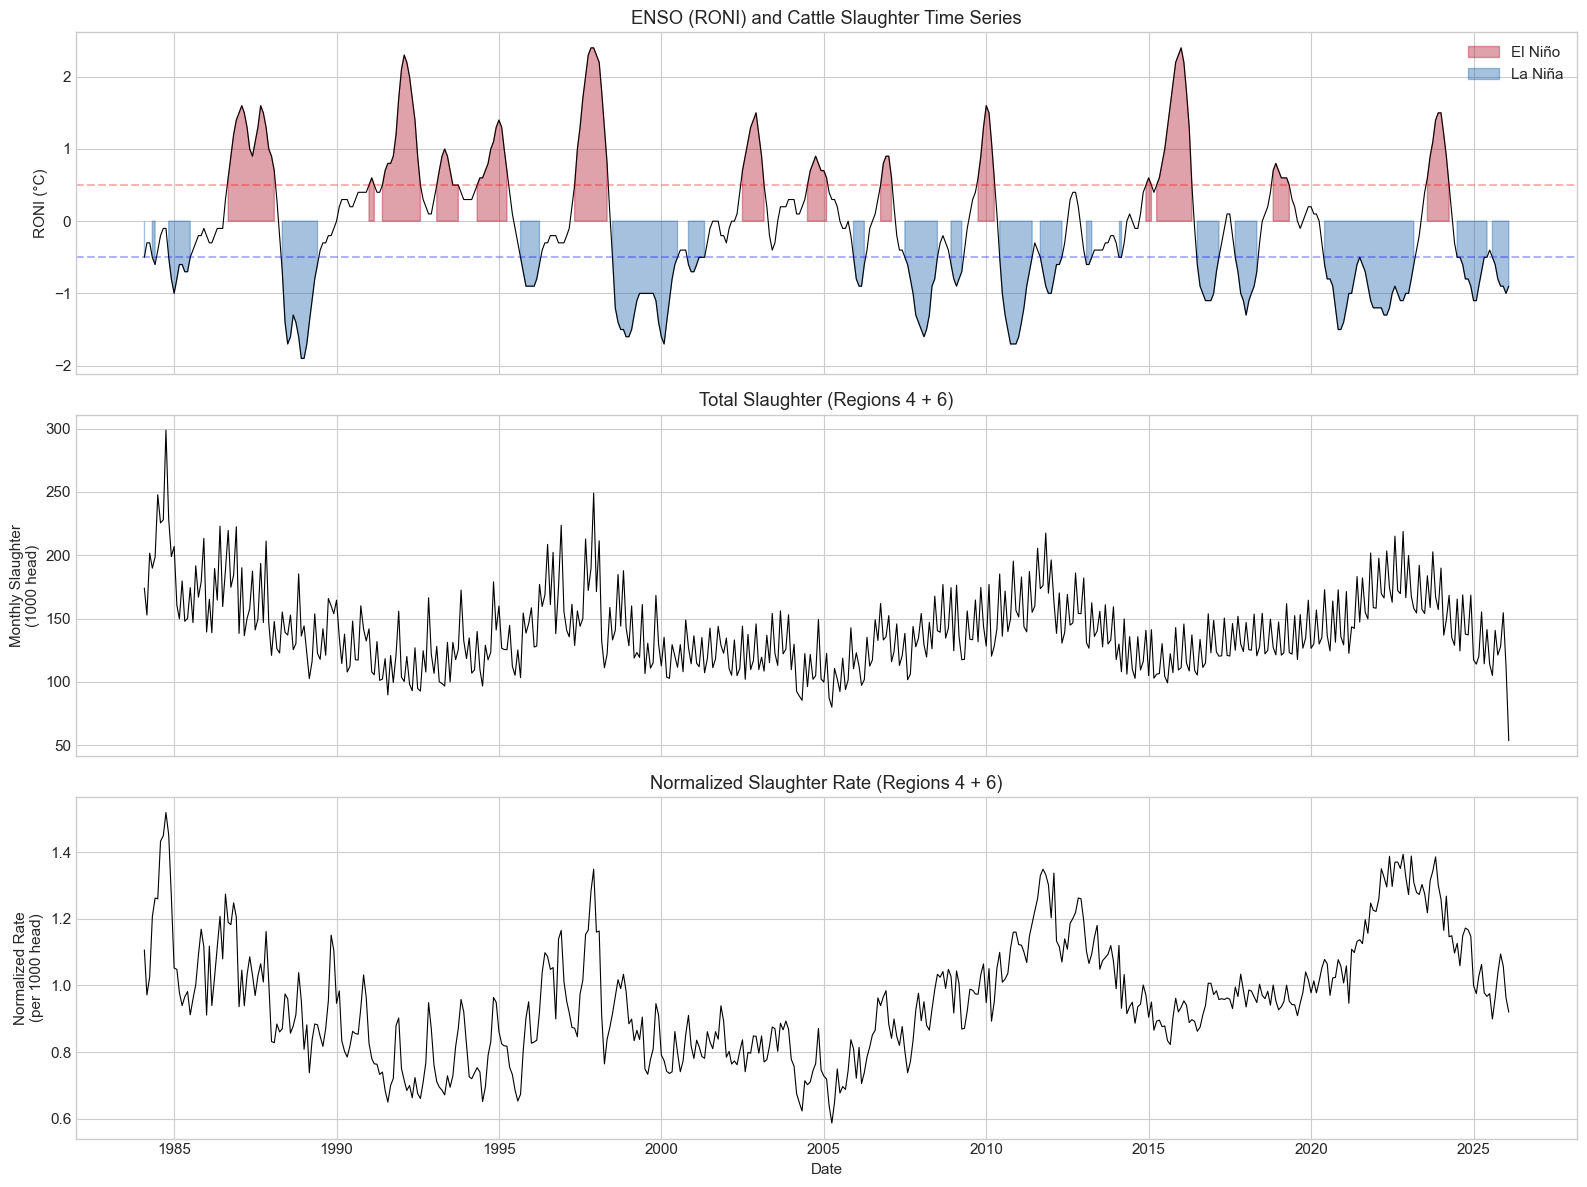

In [16]:
# Aggregate to monthly for cleaner visualization
monthly = merged.set_index('date').resample('ME').agg({
    'roni': 'mean',
    'slaughter_total': 'sum',
    'norm_slaughter_total': 'mean',
    'enso_phase': lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan
}).dropna()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# RONI
ax1.fill_between(monthly.index, monthly['roni'], 0,
                 where=monthly['roni'] >= 0.5, color='#B2182B', alpha=0.4, label='El Niño')
ax1.fill_between(monthly.index, monthly['roni'], 0,
                 where=monthly['roni'] <= -0.5, color='#2166AC', alpha=0.4, label='La Niña')
ax1.plot(monthly.index, monthly['roni'], 'k-', linewidth=0.8)
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax1.axhline(-0.5, color='blue', linestyle='--', alpha=0.3)
ax1.set_ylabel('RONI (°C)')
ax1.set_title('ENSO (RONI) and Cattle Slaughter Time Series')
ax1.legend(loc='upper right')

# Raw slaughter
ax2.plot(monthly.index, monthly['slaughter_total'], 'k-', linewidth=0.8)
ax2.set_ylabel('Monthly Slaughter\n(1000 head)')
ax2.set_title('Total Slaughter (Regions 4 + 6)')

# Normalized slaughter
ax3.plot(monthly.index, monthly['norm_slaughter_total'], 'k-', linewidth=0.8)
ax3.set_ylabel('Normalized Rate\n(per 1000 head)')
ax3.set_title('Normalized Slaughter Rate (Regions 4 + 6)')
ax3.set_xlabel('Date')

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roni_cattle_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. ENSO Events and Slaughter Anomalies

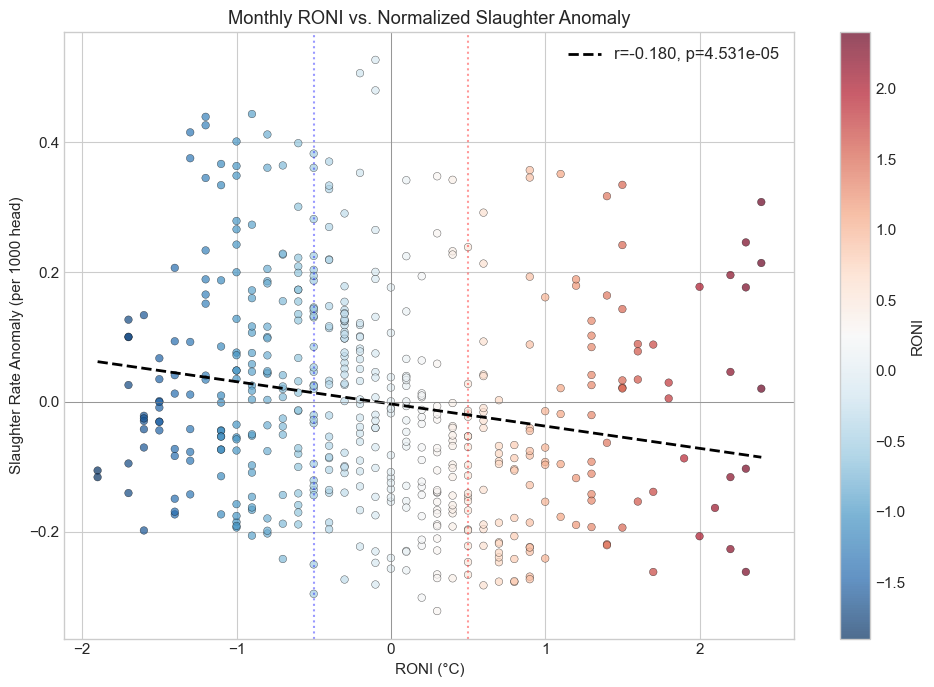


Linear regression: slope=-0.0343, r=-0.1804, p=4.5315e-05


In [17]:
# Compute slaughter anomalies (deviation from seasonal climatology)
# Seasonal climatology = mean slaughter for each week-of-year
merged['week_of_year'] = merged['date'].dt.isocalendar().week.astype(int)
climatology = merged.groupby('week_of_year')['norm_slaughter_total'].mean()
merged['slaughter_anomaly'] = merged['norm_slaughter_total'] - merged['week_of_year'].map(climatology)

# Monthly anomalies
monthly_anom = merged.set_index('date').resample('ME').agg({
    'roni': 'mean',
    'slaughter_anomaly': 'mean'
}).dropna()

# Scatter plot: RONI vs slaughter anomaly
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    monthly_anom['roni'], monthly_anom['slaughter_anomaly'],
    c=monthly_anom['roni'], cmap='RdBu_r', edgecolors='black', linewidth=0.3,
    alpha=0.7, s=30
)

# Regression line
slope, intercept, r, p, se = stats.linregress(
    monthly_anom['roni'], monthly_anom['slaughter_anomaly']
)
x_range = np.linspace(monthly_anom['roni'].min(), monthly_anom['roni'].max(), 100)
ax.plot(x_range, slope * x_range + intercept, 'k--', linewidth=2,
        label=f'r={r:.3f}, p={p:.3e}')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axvline(0.5, color='red', linestyle=':', alpha=0.4)
ax.axvline(-0.5, color='blue', linestyle=':', alpha=0.4)

ax.set_xlabel('RONI (°C)')
ax.set_ylabel('Slaughter Rate Anomaly (per 1000 head)')
ax.set_title('Monthly RONI vs. Normalized Slaughter Anomaly')
ax.legend(fontsize=12)
plt.colorbar(scatter, label='RONI')

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roni_scatter_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLinear regression: slope={slope:.4f}, r={r:.4f}, p={p:.4e}")

## 9. Strong ENSO Events Analysis

In [18]:
# Identify strong El Niño (RONI >= 1.5) and strong La Niña (RONI <= -1.5) events
merged['strong_phase'] = 'Moderate/Neutral'
merged.loc[merged['roni'] >= 1.5, 'strong_phase'] = 'Strong El Niño'
merged.loc[merged['roni'] <= -1.5, 'strong_phase'] = 'Strong La Niña'

print("Strong ENSO events (RONI-based):")
print(merged['strong_phase'].value_counts())

# Compare slaughter during strong events
strong_stats = merged.groupby('strong_phase').agg({
    'norm_slaughter_total': ['mean', 'std', 'count'],
    'slaughter_anomaly': ['mean', 'std']
}).round(4)

print("\nSlaughter statistics by event strength:")
strong_stats

Strong ENSO events (RONI-based):
strong_phase
Moderate/Neutral    1966
Strong El Niño       137
Strong La Niña       101
Name: count, dtype: int64

Slaughter statistics by event strength:


norm_slaughter_total               slaughter_anomaly        
                                 mean     std count              mean     std
strong_phase                                                                 
Moderate/Neutral               0.9581  0.1976  1955           -0.0006  0.1823
Strong El Niño                 0.9861  0.2209   137            0.0212  0.1924
Strong La Niña                 0.9680  0.1622   101           -0.0179  0.1045

In [19]:
# Major ENSO events with cattle impact
# Identify distinct ENSO episodes (sustained ONI above/below threshold)
major_events = [
    ('1997-98 El Niño', '1997-05', '1998-05', 'El Niño'),
    ('2015-16 El Niño', '2015-03', '2016-05', 'El Niño'),
    ('1988-89 La Niña', '1988-05', '1989-05', 'La Niña'),
    ('1998-01 La Niña', '1998-07', '2001-03', 'La Niña'),
    ('2010-12 La Niña', '2010-06', '2012-04', 'La Niña'),
    ('2020-23 La Niña', '2020-07', '2023-03', 'La Niña'),
]

print("Mean slaughter anomaly during major ENSO events:")
print("=" * 60)
for name, start, end, phase in major_events:
    mask = (merged['date'] >= start) & (merged['date'] <= end)
    event_data = merged.loc[mask, 'slaughter_anomaly']
    if len(event_data) > 0:
        print(f"  {name:25s} anomaly={event_data.mean():+.4f} (n={len(event_data)} weeks)")

Mean slaughter anomaly during major ENSO events:
  1997-98 El Niño           anomaly=+0.0967 (n=52 weeks)
  2015-16 El Niño           anomaly=-0.0497 (n=61 weeks)
  1988-89 La Niña           anomaly=-0.0675 (n=52 weeks)
  1998-01 La Niña           anomaly=-0.1150 (n=139 weeks)
  2010-12 La Niña           anomaly=+0.2113 (n=96 weeks)
  2020-23 La Niña           anomaly=+0.2411 (n=139 weeks)


## 10. Summer ENSO Effect (Heat Stress Season)

/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/3664594705.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summer_annual = summer.groupby(['year', 'enso_phase']).agg({
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_69169/3664594705.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summer_annual, x='enso_phase', y='slaughter_anomaly',


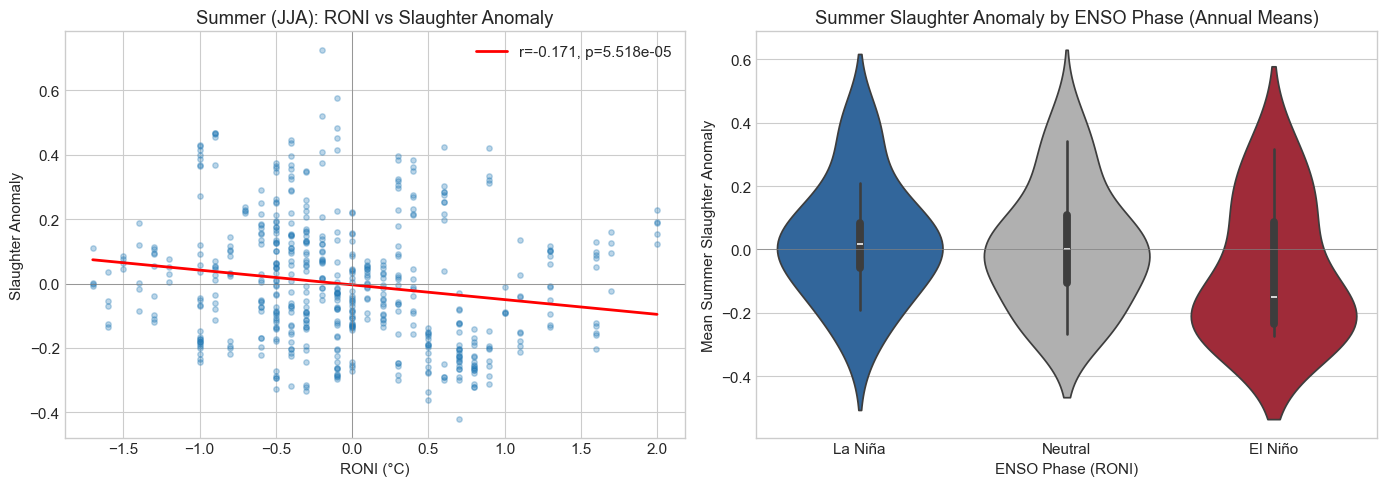


Mann-Whitney U: El Niño summer vs La Niña summer (RONI-based)
  U=nan, p=nan
  El Niño mean anomaly: -0.0723
  La Niña mean anomaly: +0.0284


In [20]:
# Focus on summer (JJA) when heat stress drives slaughter
summer = merged[merged['season'] == 'Summer'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: RONI vs summer slaughter anomaly
ax = axes[0]
ax.scatter(summer['roni'], summer['slaughter_anomaly'], alpha=0.3, s=15)
slope, intercept, r, p, se = stats.linregress(summer['roni'], summer['slaughter_anomaly'])
x_range = np.linspace(summer['roni'].min(), summer['roni'].max(), 100)
ax.plot(x_range, slope * x_range + intercept, 'r-', linewidth=2,
        label=f'r={r:.3f}, p={p:.3e}')
ax.set_xlabel('RONI (°C)')
ax.set_ylabel('Slaughter Anomaly')
ax.set_title('Summer (JJA): RONI vs Slaughter Anomaly')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

# Annual summer means by ENSO phase
summer_annual = summer.groupby(['year', 'enso_phase']).agg({
    'norm_slaughter_total': 'mean',
    'slaughter_anomaly': 'mean'
}).reset_index()

ax = axes[1]
order = ['La Niña', 'Neutral', 'El Niño']
colors = ['#2166AC', '#B0B0B0', '#B2182B']
sns.violinplot(data=summer_annual, x='enso_phase', y='slaughter_anomaly',
               order=order, palette=colors, ax=ax, inner='box')
ax.set_xlabel('ENSO Phase (RONI)')
ax.set_ylabel('Mean Summer Slaughter Anomaly')
ax.set_title('Summer Slaughter Anomaly by ENSO Phase (Annual Means)')
ax.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roni_summer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Mann-Whitney U test: El Niño summer vs La Niña summer
el_nino_summer = summer_annual[summer_annual['enso_phase'] == 'El Niño']['slaughter_anomaly']
la_nina_summer = summer_annual[summer_annual['enso_phase'] == 'La Niña']['slaughter_anomaly']
if len(el_nino_summer) > 3 and len(la_nina_summer) > 3:
    stat, pval = stats.mannwhitneyu(el_nino_summer, la_nina_summer, alternative='two-sided')
    print(f"\nMann-Whitney U: El Niño summer vs La Niña summer (RONI-based)")
    print(f"  U={stat:.1f}, p={pval:.4f}")
    print(f"  El Niño mean anomaly: {el_nino_summer.mean():+.4f}")
    print(f"  La Niña mean anomaly: {la_nina_summer.mean():+.4f}")

## 11. RONI vs ONI Comparison and Predictor Evaluation

In [21]:
# Summary and evaluation as predictor for paper_03
print("ENSO-Cattle Analysis Summary (RONI)")
print("=" * 60)
print(f"Period: {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"Total weeks analyzed: {len(merged)}")
print(f"")
print(f"RONI range: {merged['roni'].min():.2f} to {merged['roni'].max():.2f}")
print(f"El Niño weeks: {(merged['enso_phase'] == 'El Niño').sum()}")
print(f"La Niña weeks: {(merged['enso_phase'] == 'La Niña').sum()}")
print(f"Neutral weeks: {(merged['enso_phase'] == 'Neutral').sum()}")
print(f"")
print("RONI vs ONI correlation:")
roni_oni_r, roni_oni_p = stats.pearsonr(merged['roni'].dropna(), merged['oni'].dropna().iloc[:len(merged['roni'].dropna())])
print(f"  r={roni_oni_r:.4f} (p={roni_oni_p:.4e}) — highly correlated but not identical")
print(f"")
print("=" * 60)
print("PREDICTOR EVALUATION FOR paper_03_predictive_modeling:")
print("=" * 60)
print(f"")
print("Potential RONI features to add to paper_analysis_ready.csv:")
print("  1. roni          — current month RONI value (continuous)")
print("  2. roni_lag4     — 4-week lagged RONI")
print("  3. roni_lag8     — 8-week lagged RONI")  
print("  4. enso_phase    — categorical (La Niña/Neutral/El Niño)")
print("  5. roni_x_summer — RONI × summer interaction (amplified heat stress)")
print(f"")
print("Rationale:")
print("  - ENSO modulates US summer temperatures via teleconnections")
print("  - La Niña → drier/hotter summers in Southern Plains (Region 6)")
print("  - El Niño → wetter/cooler summers in Southeast (Region 4)")
print("  - RONI preferred over ONI: accounts for warming trend, NOAA standard")

ENSO-Cattle Analysis Summary (RONI)
Period: 1984-01-07 to 2026-03-28
Total weeks analyzed: 2204

RONI range: -1.90 to 2.40
El Niño weeks: 490
La Niña weeks: 820
Neutral weeks: 894

RONI vs ONI correlation:
  r=0.9590 (p=0.0000e+00) — highly correlated but not identical

PREDICTOR EVALUATION FOR paper_03_predictive_modeling:

Potential RONI features to add to paper_analysis_ready.csv:
  1. roni          — current month RONI value (continuous)
  2. roni_lag4     — 4-week lagged RONI
  3. roni_lag8     — 8-week lagged RONI
  4. enso_phase    — categorical (La Niña/Neutral/El Niño)
  5. roni_x_summer — RONI × summer interaction (amplified heat stress)

Rationale:
  - ENSO modulates US summer temperatures via teleconnections
  - La Niña → drier/hotter summers in Southern Plains (Region 6)
  - El Niño → wetter/cooler summers in Southeast (Region 4)
  - RONI preferred over ONI: accounts for warming trend, NOAA standard


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4761: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


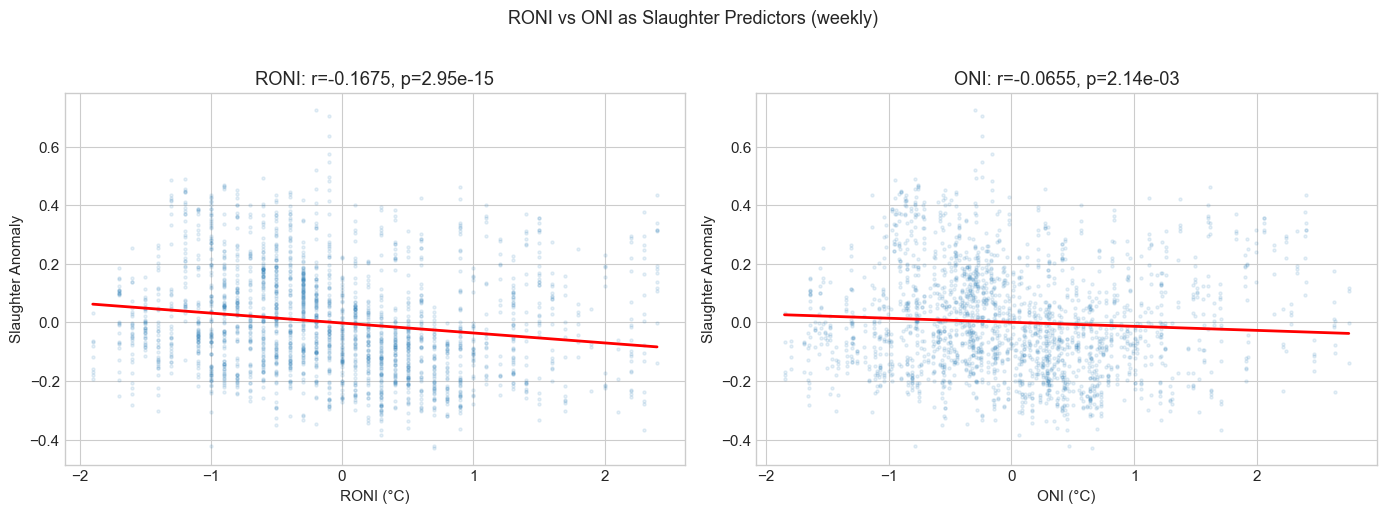


Direct comparison:
  RONI r=-0.1675 (p=2.95e-15)
  ONI  r=-0.0655 (p=2.14e-03)
  Improvement: +0.1019 in |r|
  → RONI is a stronger predictor


In [22]:
# Compare RONI vs ONI as predictors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RONI vs slaughter anomaly
ax = axes[0]
valid = merged[['roni', 'slaughter_anomaly']].dropna()
r_roni, p_roni = stats.pearsonr(valid['roni'], valid['slaughter_anomaly'])
ax.scatter(valid['roni'], valid['slaughter_anomaly'], alpha=0.1, s=5)
slope, intercept, _, _, _ = stats.linregress(valid['roni'], valid['slaughter_anomaly'])
x = np.linspace(valid['roni'].min(), valid['roni'].max(), 100)
ax.plot(x, slope * x + intercept, 'r-', linewidth=2)
ax.set_xlabel('RONI (°C)')
ax.set_ylabel('Slaughter Anomaly')
ax.set_title(f'RONI: r={r_roni:.4f}, p={p_roni:.2e}')

# ONI vs slaughter anomaly
ax = axes[1]
valid = merged[['oni', 'slaughter_anomaly']].dropna()
r_oni, p_oni = stats.pearsonr(valid['oni'], valid['slaughter_anomaly'])
ax.scatter(valid['oni'], valid['slaughter_anomaly'], alpha=0.1, s=5)
slope, intercept, _, _, _ = stats.linregress(valid['oni'], valid['slaughter_anomaly'])
x = np.linspace(valid['oni'].min(), valid['oni'].max(), 100)
ax.plot(x, slope * x + intercept, 'r-', linewidth=2)
ax.set_xlabel('ONI (°C)')
ax.set_ylabel('Slaughter Anomaly')
ax.set_title(f'ONI: r={r_oni:.4f}, p={p_oni:.2e}')

plt.suptitle('RONI vs ONI as Slaughter Predictors (weekly)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roni_vs_oni_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDirect comparison:")
print(f"  RONI r={r_roni:.4f} (p={p_roni:.2e})")
print(f"  ONI  r={r_oni:.4f} (p={p_oni:.2e})")
print(f"  Improvement: {abs(r_roni) - abs(r_oni):+.4f} in |r|")
if abs(r_roni) > abs(r_oni):
    print("  → RONI is a stronger predictor")
else:
    print("  → ONI is a stronger predictor (surprising — investigate further)")

## 13. Export RONI Features for Modeling Pipeline

Generate RONI-based features ready to merge into `paper_analysis_ready.csv` for use in `paper_03_predictive_modeling.ipynb`.

In [23]:
# Build RONI feature set aligned to the weekly cattle data
# This creates features that can be merged into paper_analysis_ready.csv

# Start from the full merged dataset (weekly cattle + RONI)
roni_features = merged[['date', 'roni', 'enso_phase']].copy()

# Lagged RONI (ENSO teleconnections have delayed effects)
for lag in [4, 8, 12, 16]:
    roni_features[f'roni_lag{lag}'] = roni_features['roni'].shift(lag)

# Rolling mean (smoothed ENSO state)
roni_features['roni_rolling4'] = roni_features['roni'].rolling(4, min_periods=1).mean()
roni_features['roni_rolling8'] = roni_features['roni'].rolling(8, min_periods=1).mean()

# ENSO phase as binary indicators
roni_features['is_el_nino'] = (roni_features['enso_phase'] == 'El Niño').astype(int)
roni_features['is_la_nina'] = (roni_features['enso_phase'] == 'La Niña').astype(int)

# Summer interaction (RONI effect amplified in summer heat stress season)
roni_features['month'] = roni_features['date'].dt.month
roni_features['is_summer'] = roni_features['month'].isin([6, 7, 8]).astype(int)
roni_features['roni_x_summer'] = roni_features['roni'] * roni_features['is_summer']

# Drop helper columns
roni_features = roni_features.drop(columns=['month', 'is_summer', 'enso_phase'])

# Save for use in paper_03
output_path = config.CATTLE_DATA_DIR / 'roni_features_weekly.csv'
roni_features.to_csv(output_path, index=False)
print(f"Saved RONI features: {roni_features.shape[1] - 1} features × {roni_features.shape[0]} weeks")
print(f"Output: {output_path}")
print(f"\nFeatures:")
for col in roni_features.columns:
    if col != 'date':
        valid = roni_features[col].dropna()
        print(f"  {col:20s} mean={valid.mean():+.3f}  std={valid.std():.3f}  n={len(valid)}")
print(f"\nTo use in paper_03, merge on 'date' column with paper_analysis_ready.csv")

Saved RONI features: 10 features × 2204 weeks
Output: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/notebooks/03_analysis/../../data/cattle_data/roni_features_weekly.csv

Features:
  roni                 mean=-0.076  std=0.888  n=2204
  roni_lag4            mean=-0.075  std=0.889  n=2200
  roni_lag8            mean=-0.074  std=0.889  n=2196
  roni_lag12           mean=-0.072  std=0.890  n=2192
  roni_lag16           mean=-0.071  std=0.890  n=2188
  roni_rolling4        mean=-0.076  std=0.885  n=2204
  roni_rolling8        mean=-0.076  std=0.880  n=2204
  is_el_nino           mean=+0.222  std=0.416  n=2204
  is_la_nina           mean=+0.372  std=0.483  n=2204
  roni_x_summer        mean=-0.016  std=0.361  n=2204

To use in paper_03, merge on 'date' column with paper_analysis_ready.csv


## 14. Outlier Analysis: RONI During Extreme Slaughter Weeks

Identify outlier slaughter weeks (IQR method) and characterize their ENSO state.
This reveals whether extreme cattle mortality events preferentially occur during
specific ENSO phases — critical for early warning systems.

In [24]:
# Identify outliers using IQR method per region
outlier_records = []

for region_col, norm_col, label in [
    ('slaughter_r4', 'norm_slaughter_r4', 'Region 4'),
    ('slaughter_r6', 'norm_slaughter_r6', 'Region 6'),
]:
    for col, col_label in [(region_col, 'Raw'), (norm_col, 'Normalized')]:
        Q1 = merged[col].quantile(0.25)
        Q3 = merged[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_threshold = Q3 + 1.5 * IQR
        lower_threshold = Q1 - 1.5 * IQR
        
        upper_outliers = merged[merged[col] > upper_threshold].copy()
        lower_outliers = merged[merged[col] < lower_threshold].copy()
        
        upper_outliers['outlier_type'] = 'High'
        lower_outliers['outlier_type'] = 'Low'
        upper_outliers['region_label'] = label
        upper_outliers['metric'] = col_label
        lower_outliers['region_label'] = label
        lower_outliers['metric'] = col_label
        
        outlier_records.append(upper_outliers)
        outlier_records.append(lower_outliers)
        
        print(f"{label} ({col_label}):")
        print(f"  IQR: {IQR:.3f}, Upper: {upper_threshold:.3f}, Lower: {lower_threshold:.3f}")
        print(f"  High outliers: {len(upper_outliers)}, Low outliers: {len(lower_outliers)}")

all_outliers = pd.concat(outlier_records, ignore_index=True)
print(f"\nTotal outlier records: {len(all_outliers)}")


Region 4 (Raw):
  IQR: 3.700, Upper: 20.250, Lower: 5.450
  High outliers: 89, Low outliers: 0
Region 4 (Normalized):
  IQR: 0.304, Upper: 1.769, Lower: 0.554
  High outliers: 30, Low outliers: 2
Region 6 (Raw):
  IQR: 6.600, Upper: 31.900, Lower: 5.500
  High outliers: 18, Low outliers: 1
Region 6 (Normalized):
  IQR: 0.339, Upper: 1.519, Lower: 0.161
  High outliers: 7, Low outliers: 0

Total outlier records: 147


In [25]:
# What RONI values do outliers have?
# Focus on HIGH outliers (extreme slaughter weeks)
high_outliers = all_outliers[all_outliers['outlier_type'] == 'High'].copy()

print("=== RONI During HIGH Slaughter Outlier Weeks ===\n")

# ENSO phase distribution for outliers vs all data
print("ENSO phase distribution:")
print(f"  {'Phase':<12s} {'All weeks':>10s} {'Outliers':>10s} {'Enrichment':>12s}")
print("-" * 48)
for phase in ['La Niña', 'Neutral', 'El Niño']:
    all_pct = (merged['enso_phase'] == phase).mean() * 100
    out_pct = (high_outliers['enso_phase'] == phase).mean() * 100 if len(high_outliers) > 0 else 0
    enrichment = out_pct / all_pct if all_pct > 0 else 0
    marker = ' ←' if enrichment > 1.3 else ''
    print(f"  {phase:<12s} {all_pct:>9.1f}% {out_pct:>9.1f}% {enrichment:>10.2f}x{marker}")

print(f"\n--- RONI statistics ---")
print(f"  All weeks:  RONI mean={merged['roni'].mean():+.3f}, std={merged['roni'].std():.3f}")
print(f"  Outliers:   RONI mean={high_outliers['roni'].mean():+.3f}, std={high_outliers['roni'].std():.3f}")

# Statistical test: is RONI different for outlier weeks?
from scipy import stats
stat, pval = stats.mannwhitneyu(
    high_outliers['roni'].dropna(), 
    merged['roni'].dropna(), 
    alternative='two-sided'
)
print(f"  Mann-Whitney U: p={pval:.4e} {'(significant)' if pval < 0.05 else '(not significant)'}")

# Per-region breakdown
print(f"\n--- By region ---")
for region in ['Region 4', 'Region 6']:
    subset = high_outliers[high_outliers['region_label'] == region]
    if len(subset) > 0:
        print(f"\n  {region} high outliers (n={len(subset)}):")
        print(f"    RONI mean: {subset['roni'].mean():+.3f}")
        print(f"    ENSO phases: {dict(subset['enso_phase'].value_counts())}")
        print(f"    Seasons: {dict(subset['season'].value_counts())}")
        print(f"    Year range: {subset['year'].min()}-{subset['year'].max()}")


=== RONI During HIGH Slaughter Outlier Weeks ===

ENSO phase distribution:
  Phase         All weeks   Outliers   Enrichment
------------------------------------------------
  La Niña           37.2%      10.4%       0.28x
  Neutral           40.6%      31.9%       0.79x
  El Niño           22.2%      57.6%       2.59x ←

--- RONI statistics ---
  All weeks:  RONI mean=-0.076, std=0.888
  Outliers:   RONI mean=+0.965, std=1.143
  Mann-Whitney U: p=2.9503e-23 (significant)

--- By region ---

  Region 4 high outliers (n=119):
    RONI mean: +1.215
    ENSO phases: {'El Niño': np.int64(83), 'Neutral': np.int64(25), 'La Niña': np.int64(11)}
    Seasons: {'Fall': np.int64(51), 'Summer': np.int64(38), 'Winter': np.int64(28), 'Spring': np.int64(2)}
    Year range: 1984-2024

  Region 6 high outliers (n=25):
    RONI mean: -0.224
    ENSO phases: {'Neutral': np.int64(21), 'La Niña': np.int64(4), 'El Niño': np.int64(0)}
    Seasons: {'Summer': np.int64(13), 'Fall': np.int64(11), 'Spring': np.i

=== Top 20 Most Extreme High-Slaughter Weeks ===

      date   roni enso_phase season  slaughter_r4  slaughter_r6  slaughter_total  norm_slaughter_r4  norm_slaughter_r6
1984-09-15 -0.100    Neutral   Fall        24.000        40.600           64.600              1.624              1.654
1984-09-08 -0.100    Neutral   Fall        23.300        39.700           63.000              1.577              1.618
1984-08-25 -0.100    Neutral Summer        24.300        37.900           62.200              1.644              1.544
1984-09-22 -0.100    Neutral   Fall        22.700        39.300           62.000              1.536              1.601
1984-09-29 -0.100    Neutral   Fall        22.500        37.300           59.800              1.522              1.520
1984-07-14 -0.200    Neutral Summer        21.500        37.900           59.400              1.455              1.544
1984-07-07 -0.200    Neutral Summer        21.600        37.500           59.100              1.462              1.52

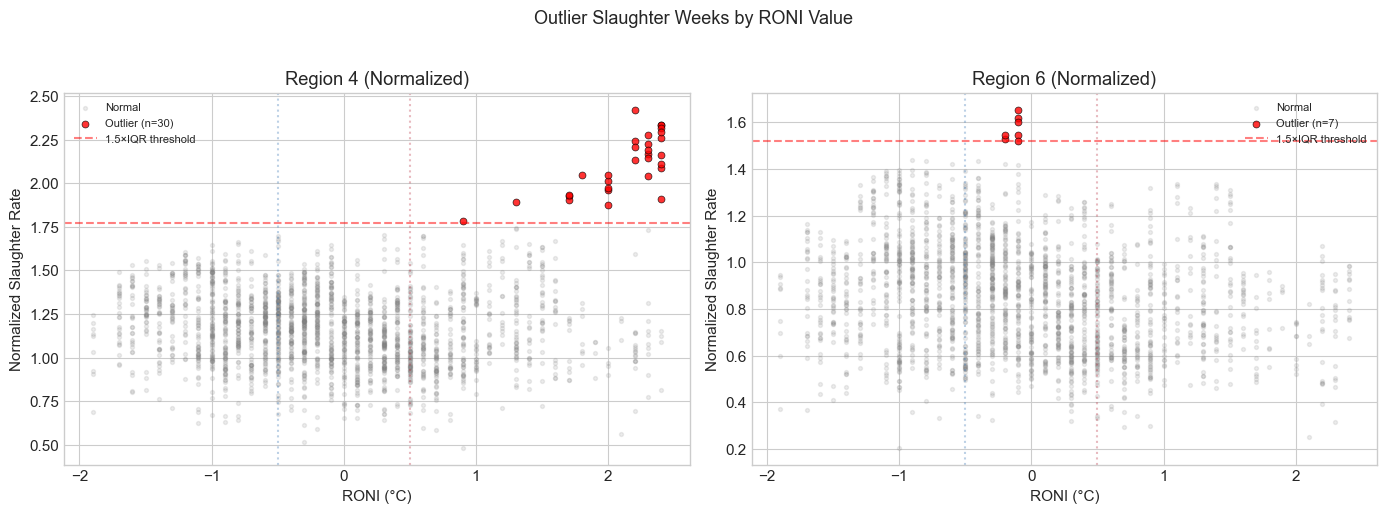

In [26]:
# Show the actual outlier weeks with dates, RONI values, and slaughter
print("=== Top 20 Most Extreme High-Slaughter Weeks ===\n")

# Get unique outlier dates with their details
outlier_detail = high_outliers.drop_duplicates(subset='date').sort_values('date')

# For each, show date, RONI, phase, season, slaughter values
detail_df = outlier_detail[['date', 'roni', 'enso_phase', 'season',
                             'slaughter_r4', 'slaughter_r6', 'slaughter_total',
                             'norm_slaughter_r4', 'norm_slaughter_r6']].copy()
detail_df['date'] = detail_df['date'].dt.strftime('%Y-%m-%d')

# Sort by total slaughter descending
detail_df = detail_df.sort_values('slaughter_total', ascending=False).head(20)

print(detail_df.to_string(index=False, float_format='%.3f'))

# Scatter: highlight outliers on the RONI vs slaughter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['norm_slaughter_r4', 'norm_slaughter_r6'],
                           ['Region 4 (Normalized)', 'Region 6 (Normalized)']):
    Q1 = merged[col].quantile(0.25)
    Q3 = merged[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    
    normal = merged[merged[col] <= upper]
    outlier = merged[merged[col] > upper]
    
    ax.scatter(normal['roni'], normal[col], alpha=0.15, s=8, color='gray', label='Normal')
    ax.scatter(outlier['roni'], outlier[col], alpha=0.8, s=25, color='red', 
               edgecolors='black', linewidth=0.5, label=f'Outlier (n={len(outlier)})')
    ax.axhline(upper, color='red', linestyle='--', alpha=0.5, label=f'1.5×IQR threshold')
    ax.axvline(0.5, color='#B2182B', linestyle=':', alpha=0.3)
    ax.axvline(-0.5, color='#2166AC', linestyle=':', alpha=0.3)
    ax.set_xlabel('RONI (°C)')
    ax.set_ylabel('Normalized Slaughter Rate')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Outlier Slaughter Weeks by RONI Value', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roni_outlier_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
